In [3]:
# ==============================================================================
# PROYECTO: Análisis Exploratorio de Datos (EDA) y Correlación de Películas
# ==============================================================================
# OBJETIVO:
# Analizar qué variables influyen de manera directa en el éxito financiero 
# (recaudación en taquilla) de una película a partir de un registro histórico.
#
# HIPÓTESIS:
# 1) A mayor presupuesto invertido (budget) --> mayor recaudación (gross)
# 2) Cuanto más grande/reconocida la empresa productora (company) --> mayor recaudación (gross)
# ==============================================================================

In [7]:
# !pip install pandas numpy seaborn matplotlib

In [5]:
# Importación de librerías para manipulación y visualización de datos
import pandas as pd     # Manipulación y análisis tabular de datos
import numpy as np      # Operaciones numéricas y cálculo de nulos
import seaborn as sns   # Visualización estadística avanzada

import matplotlib
import matplotlib.pyplot as plt

# Configuración del estilo visual y tamaño predeterminado de los gráficos
plt.style.use('ggplot')
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8)

# Desactivar advertencias de asignaciones encadenadas en pandas
pd.options.mode.chained_assignment = None

# Lectura del conjunto de datos
df = pd.read_csv(r'C:\Users\Nico\OneDrive\Educacion-IT\Portolio\Proyecto 4\movies.csv')

In [8]:
# Vista preliminar de las primeras 5 filas del dataset
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [ ]:
#  [1. Inspección] ──> [2. Limpieza] ──> [3. Transformación] ──> [4. Exploración]

In [58]:
# ==============================================================================
# 1. AUDITORÍA DE CALIDAD: Detección de valores nulos o faltantes
# ==============================================================================
# Iteramos sobre cada columna para calcular el porcentaje de valores nulos
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing * 100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%
yearcorrect - 0%


In [59]:
# ==============================================================================
# 1. INSPECCIÓN DE ESTRUCTURA: Tipos de datos iniciales
# ==============================================================================
# Verificamos el tipo de dato asignado por pandas a cada columna
print(df.dtypes)

name               str
rating             str
genre              str
year             int64
released           str
score          float64
votes          float64
director           str
writer             str
star               str
country            str
budget           Int64
gross            Int64
company            str
runtime        float64
yearcorrect        str
dtype: object


In [60]:
# ==============================================================================
# 2. LIMPIEZA DE DATOS: Conversión y casteo de tipos de datos
# ==============================================================================
# Convertimos 'budget' y 'gross' a enteros con soporte para valores nulos (Int64)
# Se utiliza 'Int64' con "I" mayúscula para permitir enteros nulables en pandas
df['budget'] = df['budget'].astype('Int64')
df['gross'] = df['gross'].astype('Int64')

# Verificamos que la conversión se haya aplicado correctamente
print(df.dtypes)

name               str
rating             str
genre              str
year             int64
released           str
score          float64
votes          float64
director           str
writer             str
star               str
country            str
budget           Int64
gross            Int64
company            str
runtime        float64
yearcorrect        str
dtype: object


In [61]:
# ==============================================================================
# 3. TRANSFORMACIÓN: Normalización del año de estreno 
# ==============================================================================
# Extraemos los 4 dígitos correspondientes al año desde el texto de 'released'
# para corregir posibles discrepancias con la columna 'year' original
df['yearcorrect'] = df['released'].astype(str).str.extract(r'(\d{4})')

# Visualizamos las primeras 9 filas para verificar la nueva columna creada
df.head(9)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018
7480,The Lion King,PG,Animation,2019,"July 19, 2019 (United States)",6.9,222000.0,Jon Favreau,Jeff Nathanson,Donald Glover,United States,260000000,1670727580,Walt Disney Pictures,118.0,2019
6653,Jurassic World,PG-13,Action,2015,"June 12, 2015 (United States)",7.0,593000.0,Colin Trevorrow,Rick Jaffa,Chris Pratt,United States,150000000,1670516444,Universal Pictures,124.0,2015
6043,The Avengers,PG-13,Action,2012,"May 4, 2012 (United States)",8.0,1300000.0,Joss Whedon,Joss Whedon,Robert Downey Jr.,United States,220000000,1518815515,Marvel Studios,143.0,2012
6646,Furious 7,PG-13,Action,2015,"April 3, 2015 (United States)",7.1,370000.0,James Wan,Chris Morgan,Vin Diesel,United States,190000000,1515341399,Universal Pictures,137.0,2015


In [62]:
# ==============================================================================
# 4. EXPLORACIÓN: Correlacion de datos
# ==============================================================================
# Ordenamos el conjunto de datos por recaudación de mayor a menor
df = df.sort_values(by=['gross'], ascending=False)

# Visualizamos las primeras 5 películas antes de analizar correlaciones
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


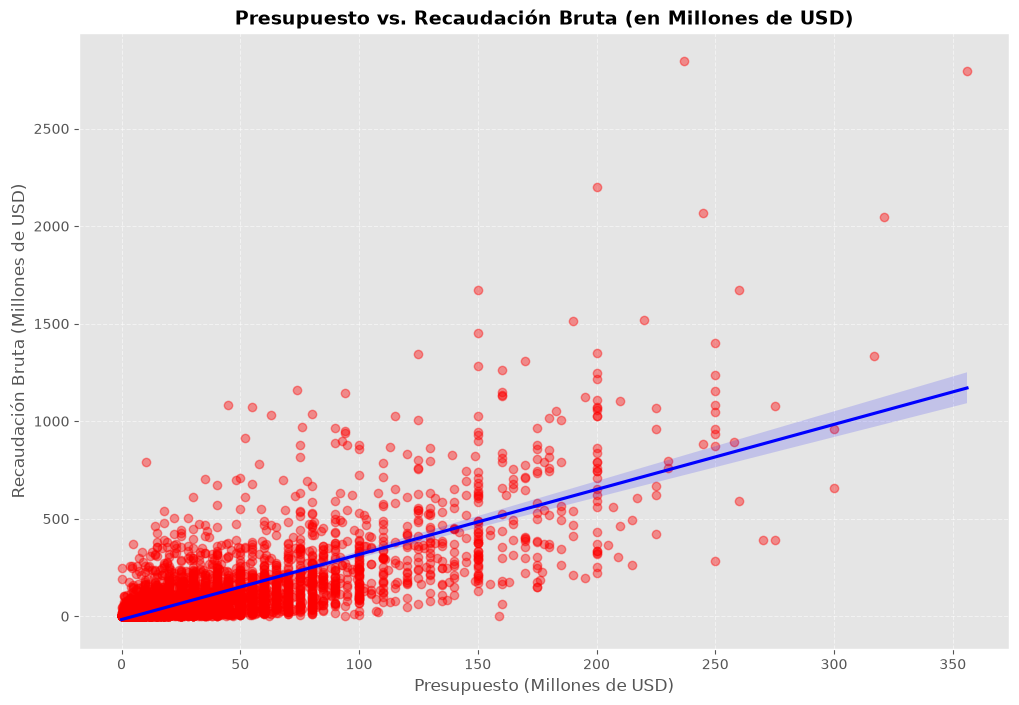

In [63]:
# HIPÓTESIS 1: Presupuesto vs. Recaudación Bruta (Visualización)
# Seaborn grafica la dispersión de puntos y ajusta la recta de regresión lineal
# Dividimos por 1e6 para presentar ambos ejes en millones de USD
sns.regplot(
    x=df['budget'] / 1e6, 
    y=df['gross'] / 1e6, 
    data=df,
    scatter_kws={"color": "red", "alpha": 0.4}, 
    line_kws={"color": "blue"}
)

plt.title('Presupuesto vs. Recaudación Bruta (en Millones de USD)', fontsize=14, fontweight='bold')
plt.xlabel('Presupuesto (Millones de USD)', fontsize=12)
plt.ylabel('Recaudación Bruta (Millones de USD)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [64]:
# HIPÓTESIS 1: Matriz de correlación lineal de Pearson
# Calculamos los coeficientes de correlación entre todas las variables numéricas
df.corr(method='pearson', numeric_only=True)

,year,score,votes,budget,gross,runtime
year,1.000000,0.097995,0.222945,0.329321,0.257486,0.120811
score,0.097995,1.000000,0.409182,0.076254,0.186258,0.399451
votes,0.222945,0.409182,1.000000,0.442429,0.630757,0.309212
budget,0.329321,0.076254,0.442429,1.000000,0.740395,0.320447
gross,0.257486,0.186258,0.630757,0.740395,1.000000,0.245216
runtime,0.120811,0.399451,0.309212,0.320447,0.245216,1.000000


In [65]:
# Para Presupuesto vs Recaudación solamente:
df['budget'].corr(df['gross'], method='pearson')

np.float64(0.7403948929894826)

In [66]:
# Nota: En este dataset clásico de películas de IMDb/Kaggle, ese cálculo suele dar un valor aproximado de $ 0.74, lo que formalmente se clasifica como una correlación positiva considerable/fuerte. Ademas notar como es el mas alto entre el resto.

In [67]:
# Para tener en cuenta: Los 3 métodos de correlación que soporta Pandas en df.corr() son 'pearson', 'kendall' y 'spearman'.

In [68]:
# !pip install scipy

In [69]:
# 1. Pearson (el estándar lineal por defecto)
# df.corr(method='pearson', numeric_only=True)

# 2. Kendall (Kendall Tau - basado en rangos/pares concordantes)
df.corr(method='kendall', numeric_only=True)

# 3. Spearman (Spearman Rank - basado en rangos de orden)
# df.corr(method='spearman', numeric_only=True)

,year,score,votes,budget,gross,runtime
year,1.000000,0.067652,0.331465,0.224120,0.200618,0.097184
score,0.067652,1.000000,0.300115,-0.000566,0.086046,0.283611
votes,0.331465,0.300115,1.000000,0.353702,0.548899,0.198240
budget,0.224120,-0.000566,0.353702,1.000000,0.512637,0.235483
gross,0.200618,0.086046,0.548899,0.512637,1.000000,0.168933
runtime,0.097184,0.283611,0.198240,0.235483,0.168933,1.000000


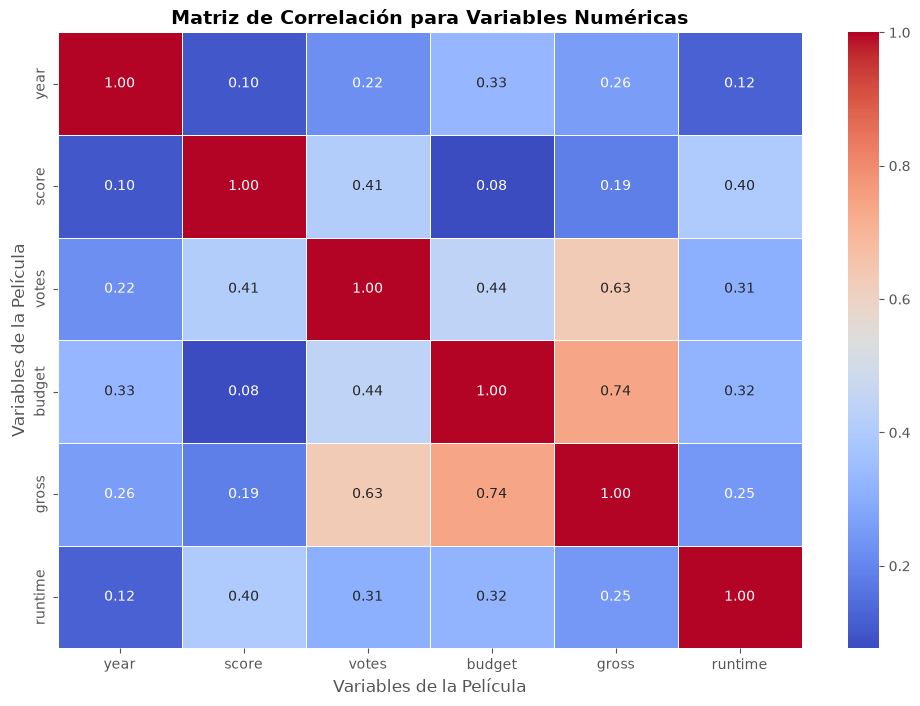

In [70]:
# HIPÓTESIS 1: Matriz de correlación y mapa de calor (Variables numéricas)
# Calculamos la correlación de Pearson sobre las variables numéricas
matriz_correlacion = df.corr(method='pearson', numeric_only=True)

# Visualizamos la matriz mediante un mapa de calor (Heatmap)
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación para Variables Numéricas', fontsize=14, fontweight='bold')
plt.xlabel('Variables de la Película', fontsize=12)
plt.ylabel('Variables de la Película', fontsize=12)

plt.show()

In [71]:
# Conclusion de la 1era hipostesis: es correcto, a mayor presupuesto en una pelicula mayor es la probabilidad de recaudar mas.

In [72]:
# HIPÓTESIS 2: Preparación y codificación de variables cualitativas
# Creamos una copia de trabajo para codificar variables categóricas sin alterar el df original
df_numerized = df.copy()

# Identificamos las columnas de texto y las convertimos a valores numéricos enteros
columnas_categoricas = df_numerized.select_dtypes(exclude=['number']).columns

for col in columnas_categoricas:
    df_numerized[col] = df_numerized[col].astype('category').cat.codes

# Visualizamos las primeras filas para confirmar que todas las columnas son numéricas
df_numerized.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,29
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,39
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,17
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,35
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,38


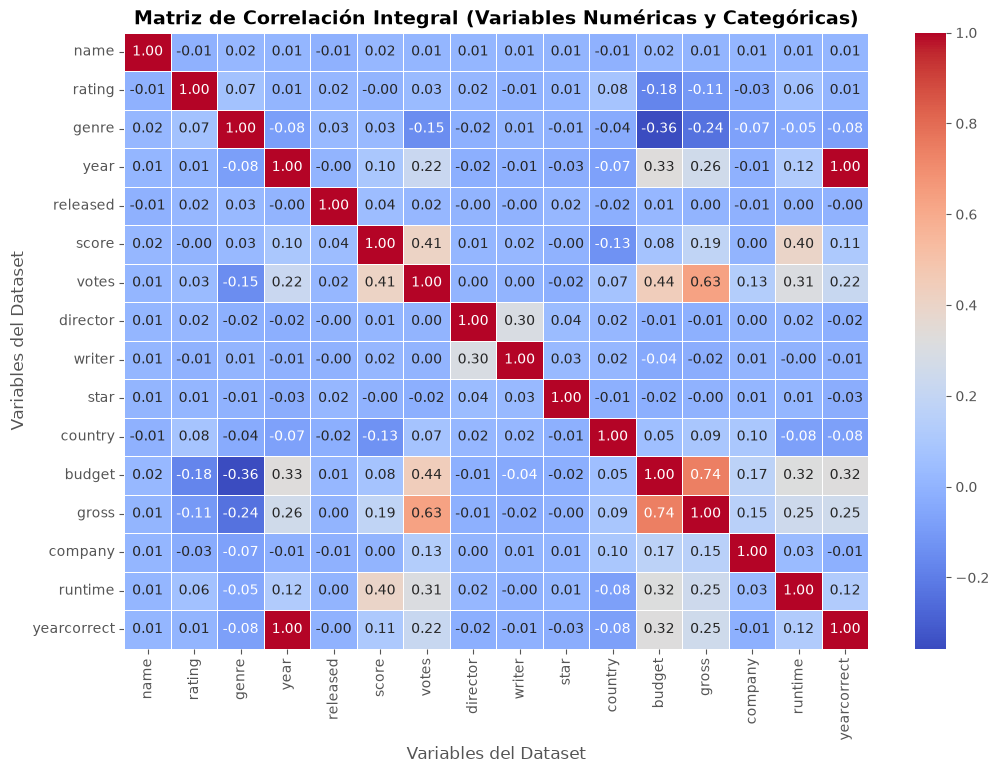

In [73]:
# HIPÓTESIS 2: Matriz de correlación global y mapa de calor integral
# Calculamos la correlación de Pearson considerando todas las variables del dataset
matriz_completa = df_numerized.corr(method='pearson')

# Generamos el mapa de calor para visualizar las interacciones entre variables
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_completa, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Matriz de Correlación Integral (Variables Numéricas y Categóricas)', fontsize=14, fontweight='bold')
plt.xlabel('Variables del Dataset', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)

plt.show()

In [74]:
# CONCLUSIONES: Desdoblamiento de matriz y filtrado de correlaciones fuertes
# Transformamos la matriz en pares ordenados (unstack)
pares_correlacion = matriz_completa.unstack().sort_values()

# Filtramos las relaciones con correlación estadísticamente significativa (|r| > 0.5)
# descartando las diagonales de autocorrección perfecta (r = 1.0)
correlaciones_fuertes = pares_correlacion[(abs(pares_correlacion) > 0.5) & (pares_correlacion < 0.99)]

print("=== VARIABLES CON ALTA CORRELACIÓN CON LA RECAUDACIÓN (GROSS) ===")
print(correlaciones_fuertes)

=== VARIABLES CON ALTA CORRELACIÓN CON LA RECAUDACIÓN (GROSS) ===
gross   votes     0.630757
votes   gross     0.630757
gross   budget    0.740395
budget  gross     0.740395
dtype: float64


In [75]:
# Conclusión de negocio:
# 1. Hipótesis 1 (Aceptada): 'budget' y 'gross' presentan una correlación alta (~0.74).
# 2. Hipótesis 2 (Refutada): 'company' presenta una correlación débil con la taquilla (<0.20).
# 3. Hallazgo adicional: 'votes' (popularidad/opinión pública) es el segundo factor más correlacionado (~0.63).